# GSEA-Based Cell Type Annotation of cNMF Gene Expression Programs

**Logic:**
1. For each K, load the usage matrix (cells × GEPs)
2. For each GEP, rank all cells by their usage score
3. Treat cell type annotations as "gene sets" (i.e., sets of cell barcodes)
4. Run GSEA prerank: walk down the ranked cell list and compute enrichment for each cell type
5. Collect NES scores → one CSV per K value (rows = GEPs, columns = cell types)

## 0. Setup

In [2]:
import os
import glob
import re
import pandas as pd
import numpy as np
import gseapy as gp
from pathlib import Path
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

## 1. Configuration

**Update these paths to match your setup.**

In [4]:
# Folder containing all cNMF result files
CNMF_DIR = "cnmf_results_S1_k3-30"

# cNMF run name prefix (the part before .usages., .gene_spectra_score., etc.)
CNMF_PREFIX = "anal_pc5_c21_S1.filtered"  

# Density threshold used in cNMF (appears in filenames as dt_0_01, dt_0_02, etc.)
DENSITY_THRESHOLD = "0_01"  

# Path to cell type metadata file
# Expected: a CSV/TSV with at least two columns:
#   - one column with cell barcodes (matching the index of the usage matrix)
#   - one column with cell type annotations
METADATA_PATH = "data/anal_cancer_n21_meta.csv"

# Column names in the metadata file
BARCODE_COL = None    # Set to column name if barcodes are NOT the index; None = use index
CELLTYPE_COL = "cluster_annot3"  # Column containing cell type annotations

# Separator for metadata file
METADATA_SEP = "," 

# Output directory for NES CSVs
OUTPUT_DIR = "gsea_celltype_results"

# K range
K_MIN = 3
K_MAX = 30

# GSEA parameters
GSEA_PERMUTATIONS = 1000  # Number of permutations for significance testing
GSEA_SEED = 42
GSEA_THREADS = 4  # Number of parallel threads
MIN_SET_SIZE = 15  # Minimum number of cells in a cell type to include

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Configuration loaded.")

Configuration loaded.


## 2. Load Cell Type Annotations & Build Cell Type Sets

In [5]:
# Load metadata
meta = pd.read_csv(METADATA_PATH, sep=METADATA_SEP, index_col=0 if BARCODE_COL is None else None)

if BARCODE_COL is not None:
    meta = meta.set_index(BARCODE_COL)

# Ensure index is string
meta.index = meta.index.astype(str)

print(f"Loaded metadata for {len(meta)} cells")
print(f"\nCell type distribution:")
print(meta[CELLTYPE_COL].value_counts())

Loaded metadata for 304634 cells

Cell type distribution:
cluster_annot3
Tumor/Epithelials      171927
Fibroblasts/Stromal     33617
Plasma_XBP1             30276
Endothelials            13279
Mac_C1Q_ZEB2            11520
CD8+Tcells               8802
CD4+Tcells               7574
Tregs                    4528
Bcells_CD19              3986
Mac_C1Q_SPP1             2586
NKcells                  2509
Mon_VCAN                 2489
Mast                     2463
DC_CD207                 2376
CD8+Tcells_Ki67          1868
Neutrophils              1818
DC_LAMP3                 1412
DC_CLEC9A                 838
pDCs                      766
Name: count, dtype: int64


In [6]:
# Build cell type "gene sets" dictionary: {cell_type: [list of barcodes]}
celltype_sets = {}
for ct, group in meta.groupby(CELLTYPE_COL):
    barcodes = group.index.tolist()
    if len(barcodes) >= MIN_SET_SIZE:
        celltype_sets[ct] = barcodes
    else:
        print(f"  Skipping '{ct}' — only {len(barcodes)} cells (min={MIN_SET_SIZE})")

print(f"\n{len(celltype_sets)} cell types included in GSEA:")
for ct, barcodes in sorted(celltype_sets.items(), key=lambda x: -len(x[1])):
    print(f"  {ct}: {len(barcodes)} cells")


19 cell types included in GSEA:
  Tumor/Epithelials: 171927 cells
  Fibroblasts/Stromal: 33617 cells
  Plasma_XBP1: 30276 cells
  Endothelials: 13279 cells
  Mac_C1Q_ZEB2: 11520 cells
  CD8+Tcells: 8802 cells
  CD4+Tcells: 7574 cells
  Tregs: 4528 cells
  Bcells_CD19: 3986 cells
  Mac_C1Q_SPP1: 2586 cells
  NKcells: 2509 cells
  Mon_VCAN: 2489 cells
  Mast: 2463 cells
  DC_CD207: 2376 cells
  CD8+Tcells_Ki67: 1868 cells
  Neutrophils: 1818 cells
  DC_LAMP3: 1412 cells
  DC_CLEC9A: 838 cells
  pDCs: 766 cells


## 3. Discover Available K Values

In [7]:
# Find all usage matrix files and extract K values
usage_pattern = os.path.join(CNMF_DIR, f"{CNMF_PREFIX}.usages.k_*.dt_{DENSITY_THRESHOLD}.consensus.txt")
usage_files = sorted(glob.glob(usage_pattern))

# Extract K values from filenames
k_values = []
for f in usage_files:
    match = re.search(r'k_(\d+)', os.path.basename(f))
    if match:
        k = int(match.group(1))
        if K_MIN <= k <= K_MAX:
            k_values.append(k)

k_values = sorted(k_values)
print(f"Found {len(k_values)} K values: {k_values}")

Found 28 K values: [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]


## 4. Run GSEA for Each K and Each GEP

For each GEP within a given K:
1. Extract usage scores for that GEP (one value per cell)
2. Use these as the "preranked" metric
3. Run `gseapy.prerank` with cell type sets
4. Collect NES for each cell type

In [6]:
def run_gsea_for_k(k, cnmf_dir, prefix, dt, celltype_sets, meta):
    """
    For a given K, load the usage matrix, run GSEA prerank for each GEP,
    and return a DataFrame of NES scores (GEPs x cell types).
    """
    # Load usage matrix
    usage_path = os.path.join(cnmf_dir, f"{prefix}.usages.k_{k}.dt_{dt}.consensus.txt")
    usage = pd.read_csv(usage_path, sep='\t', index_col=0)
    usage.index = usage.index.astype(str)
    
    print(f"\n{'='*60}")
    print(f"K = {k} | {usage.shape[1]} GEPs | {usage.shape[0]} cells")
    print(f"{'='*60}")
    
    # Find overlapping cells between usage matrix and metadata
    common_cells = usage.index.intersection(meta.index)
    if len(common_cells) < len(usage):
        print(f"  Warning: {len(usage) - len(common_cells)} cells in usage matrix not found in metadata")
    usage = usage.loc[common_cells]
    
    # Filter cell type sets to only include cells present in this usage matrix
    celltype_sets_filtered = {}
    for ct, barcodes in celltype_sets.items():
        filtered = [b for b in barcodes if b in common_cells]
        if len(filtered) >= MIN_SET_SIZE:
            celltype_sets_filtered[ct] = filtered
    
    # Collect NES results
    nes_results = {}
    pval_results = {}
    fdr_results = {}
    
    for gep_col in usage.columns:
        gep_name = gep_col if isinstance(gep_col, str) else f"GEP_{gep_col}"
        
        # Rank cells by usage of this GEP
        # gseapy.prerank expects a Series or DataFrame with numeric ranking metric
        ranked_cells = usage[gep_col].sort_values(ascending=False)
        
        # Run GSEA prerank
        try:
            res = gp.prerank(
                rnk=ranked_cells,
                gene_sets=celltype_sets_filtered,
                permutation_num=GSEA_PERMUTATIONS,
                outdir=None,  # Don't write intermediate files
                seed=GSEA_SEED,
                threads=GSEA_THREADS,
                min_size=MIN_SET_SIZE,
                max_size=len(common_cells),  # No upper limit
                verbose=False,
            )
            
            # Extract NES, p-value, and FDR for each cell type
            gsea_df = res.res2d
            nes_results[gep_name] = gsea_df.set_index('Term')['NES'].to_dict()
            pval_results[gep_name] = gsea_df.set_index('Term')['NOM p-val'].to_dict()
            fdr_results[gep_name] = gsea_df.set_index('Term')['FDR q-val'].to_dict()
            
            # Print top hit
            top_ct = gsea_df.loc[gsea_df['NES'].astype(float).idxmax(), 'Term']
            top_nes = gsea_df['NES'].astype(float).max()
            print(f"  {gep_name} → top cell type: {top_ct} (NES={top_nes:.2f})")
            
        except Exception as e:
            print(f"  {gep_name} → GSEA failed: {e}")
            nes_results[gep_name] = {}
            pval_results[gep_name] = {}
            fdr_results[gep_name] = {}
    
    # Build DataFrames
    nes_df = pd.DataFrame(nes_results).T.astype(float)
    pval_df = pd.DataFrame(pval_results).T.astype(float)
    fdr_df = pd.DataFrame(fdr_results).T.astype(float)
    
    # Sort columns (cell types) alphabetically
    nes_df = nes_df.reindex(sorted(nes_df.columns), axis=1)
    pval_df = pval_df.reindex(sorted(pval_df.columns), axis=1)
    fdr_df = fdr_df.reindex(sorted(fdr_df.columns), axis=1)
    
    nes_df.index.name = 'GEP'
    pval_df.index.name = 'GEP'
    fdr_df.index.name = 'GEP'
    
    return nes_df, pval_df, fdr_df

In [ ]:
# Run GSEA for all K values
all_nes = {}  # k -> nes_df

for k in k_values:
    nes_df, pval_df, fdr_df = run_gsea_for_k(
        k=k,
        cnmf_dir=CNMF_DIR,
        prefix=CNMF_PREFIX,
        dt=DENSITY_THRESHOLD,
        celltype_sets=celltype_sets,
        meta=meta,
    )
    
    all_nes[k] = nes_df
    
    # Save NES scores (primary output)
    nes_path = os.path.join(OUTPUT_DIR, f"NES_k{k}.csv")
    nes_df.to_csv(nes_path)
    
    # Save p-values and FDR 
    pval_df.to_csv(os.path.join(OUTPUT_DIR, f"pval_k{k}.csv"))
    fdr_df.to_csv(os.path.join(OUTPUT_DIR, f"fdr_k{k}.csv"))
    
    print(f"  Saved → {nes_path}")

print(f"\nDone! All results saved to '{OUTPUT_DIR}/'.")

2026-02-13 11:56:27,048 [WARNING] Duplicated values found in preranked stats: 13.41% of genes
The order of those genes will be arbitrary, which may produce unexpected results.



K = 3 | 3 GEPs | 14133 cells


2026-02-13 11:56:27,546 [WARNING] Duplicated values found in preranked stats: 10.47% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


  1 → top cell type: Fibroblasts/Stromal (NES=1.48)


2026-02-13 11:56:28,110 [WARNING] Duplicated values found in preranked stats: 11.95% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


...

  27 → top cell type: Mon_VCAN (NES=1.02)


2026-02-13 12:00:35,160 [WARNING] Duplicated values found in preranked stats: 90.07% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


  28 → top cell type: Mast (NES=1.08)


2026-02-13 12:00:35,689 [WARNING] Duplicated values found in preranked stats: 92.45% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


  29 → top cell type: Mac_C1Q_SPP1 (NES=1.05)
  30 → top cell type: DC_CD207 (NES=1.05)
  Saved → gsea_celltype_results/NES_k30.csv

Done! All results saved to 'gsea_celltype_results/'.


## 5. Quick Summary: Top Cell Type per GEP

In [8]:
# For each K, show the dominant cell type per GEP
summary_rows = []

for k in sorted(all_nes.keys()):
    nes_df = all_nes[k]
    for gep in nes_df.index:
        top_ct = nes_df.loc[gep].idxmax()
        top_nes = nes_df.loc[gep].max()
        summary_rows.append({
            'K': k,
            'GEP': gep,
            'Top_CellType': top_ct,
            'NES': round(top_nes, 3)
        })

summary_df = pd.DataFrame(summary_rows)
summary_path = os.path.join(OUTPUT_DIR, "summary_top_celltype_per_gep.csv")
summary_df.to_csv(summary_path, index=False)

print("Top cell type assignment per GEP (all K values):")
print("="*60)
for k in sorted(all_nes.keys()):
    subset = summary_df[summary_df['K'] == k]
    print(f"\nK = {k}:")
    for _, row in subset.iterrows():
        print(f"  {row['GEP']:>15} → {row['Top_CellType']:<25} (NES={row['NES']:.2f})")

print(f"\nSummary saved to: {summary_path}")

Top cell type assignment per GEP (all K values):

K = 3:
                1 → Fibroblasts/Stromal       (NES=1.48)
                2 → DC_CD207                  (NES=1.69)
                3 → Tumor/Epithelials         (NES=1.60)

K = 4:
                1 → CD4+Tcells                (NES=1.66)
                2 → Tumor/Epithelials         (NES=1.71)
                3 → Tumor/Epithelials         (NES=1.55)
                4 → Fibroblasts/Stromal       (NES=1.47)

K = 5:
                1 → CD4+Tcells                (NES=1.70)
                2 → Tumor/Epithelials         (NES=1.70)
                3 → Tumor/Epithelials         (NES=1.55)
                4 → Fibroblasts/Stromal       (NES=1.50)
                5 → Mac_C1Q_ZEB2              (NES=1.50)

K = 6:
                1 → CD4+Tcells                (NES=1.70)
                2 → Tumor/Epithelials         (NES=1.69)
                3 → Tumor/Epithelials         (NES=1.53)
                4 → Fibroblasts/Stromal       (NES=1.50)
       

## 6. Heatmap Visualization 

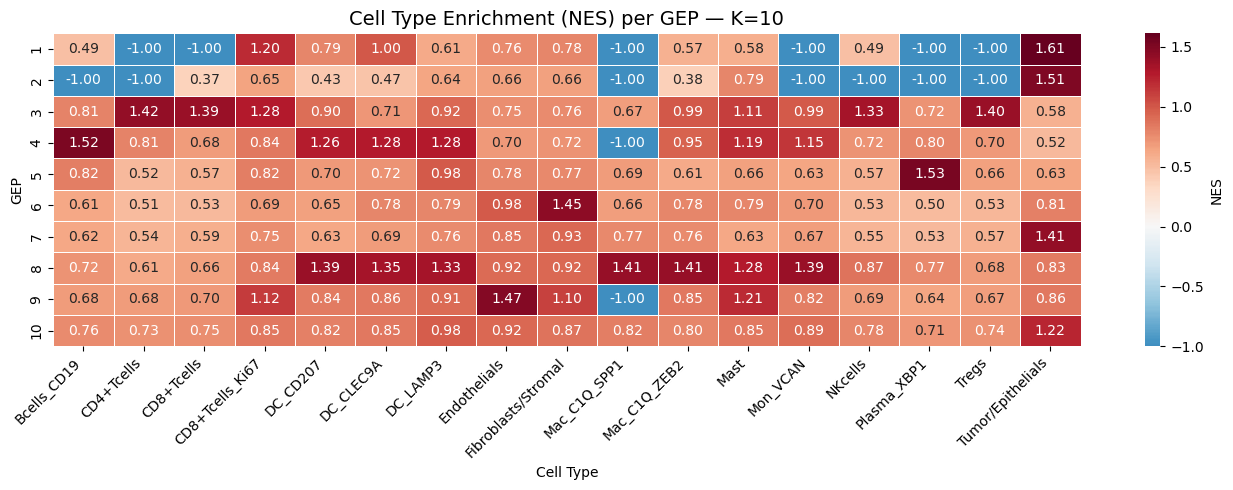

Saved: gsea_celltype_results/heatmap_NES_k10.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot a heatmap for a selected K
K_TO_PLOT = 10  

if K_TO_PLOT in all_nes:
    nes_df = all_nes[K_TO_PLOT]
    
    fig, ax = plt.subplots(figsize=(max(12, len(nes_df.columns) * 0.8), max(4, len(nes_df) * 0.5)))
    sns.heatmap(
        nes_df.astype(float),
        cmap='RdBu_r',
        center=0,
        annot=True,
        fmt='.2f',
        linewidths=0.5,
        ax=ax,
        cbar_kws={'label': 'NES'}
    )
    ax.set_title(f'Cell Type Enrichment (NES) per GEP — K={K_TO_PLOT}', fontsize=14)
    ax.set_xlabel('Cell Type')
    ax.set_ylabel('GEP')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    
    fig_path = os.path.join(OUTPUT_DIR, f"heatmap_NES_k{K_TO_PLOT}.png")
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fig_path}")
else:
    print(f"K={K_TO_PLOT} not found. Available: {sorted(all_nes.keys())}")